### Import from drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

### Import required libraries

In [3]:
!pip install metric-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu126
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.0 MB 11.2 MB/s eta 0:00:01
   ----------- ---------------------------- 2.1/7.0 MB 5.1 MB/s eta 0:00:01
   -------------------- ------------------- 3.7/7.0 MB 6.2 MB/s eta 0:00:01
   ------------------------------- -------- 5.5/7.0 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 7.7 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 2.2.1 requires pillow<12.0,>=9.2.0, but you have pillow 12.0.0 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os, sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Detect Colab
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    # Assumes drive is already mounted in a previous cell
    PROJECT_ROOT = Path("/content/drive/MyDrive/NN-kNN")
    DATA_ROOT    = Path("/content/datasets")
    CHECKPOINTS  = PROJECT_ROOT / "checkpoints"
    print("Running on Colab.")
else:
    PROJECT_ROOT = Path(os.getcwd())          # notebook's current folder as project root
    DATA_ROOT    = PROJECT_ROOT / "datasets"
    CHECKPOINTS  = PROJECT_ROOT / "checkpoints"
    print("Running locally.")

# Make project importable and set CWD to project root for consistent relative paths
# Add PROJECT_ROOT to sys.path *before* importing from within the project
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)


from model.nnknn_model import NN_KNN_Model, train_model, default_args, GlocalFeatureWeight
from model.mlkr import run_mlkr_sklearn
from datasets.reg_data import Reg_data, standardize_tensor

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT     =", DATA_ROOT)
print("CHECKPOINTS  =", CHECKPOINTS)

# Optional: pick device
try:
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
except Exception as e:
    print("Torch not available (only matters if you need it):", e)

Running locally.
PROJECT_ROOT = c:\Users\merec\Desktop\Research\NewestWork\NN-kNN
DATA_ROOT     = c:\Users\merec\Desktop\Research\NewestWork\NN-kNN\datasets
CHECKPOINTS  = c:\Users\merec\Desktop\Research\NewestWork\NN-kNN\checkpoints
Using device: cuda


In [6]:
!pip install gymnasium


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import random
from collections import deque, namedtuple
import torch.nn as nn

# DQN

### Simple DQN

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
import numpy as np
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

import os, random, torch
import gymnasium as gym
import torch.nn as nn
import torch.optim as optim
from collections import deque
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Simple DQN that gets to high accuracies

In [10]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# Replay Buffer for DQN experience
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return (
            torch.tensor(states, dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(next_states, dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)

# Epsilon-greedy policy
def select_action(state, policy_net, epsilon, action_dim):
    if random.random() < epsilon:
        return random.randrange(action_dim)
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        q_values = policy_net(state_t)
        return q_values.argmax(dim=1).item()

In [11]:
gym.pprint_registry()


===== classic_control =====
Acrobot-v1             CartPole-v0            CartPole-v1
MountainCar-v0         MountainCarContinuous-v0 Pendulum-v1
===== phys2d =====
phys2d/CartPole-v0     phys2d/CartPole-v1     phys2d/Pendulum-v0
===== box2d =====
BipedalWalker-v3       BipedalWalkerHardcore-v3 CarRacing-v3
LunarLander-v3         LunarLanderContinuous-v3
===== toy_text =====
Blackjack-v1           CliffWalking-v1        CliffWalkingSlippery-v1
FrozenLake-v1          FrozenLake8x8-v1       Taxi-v3
===== tabular =====
tabular/Blackjack-v0   tabular/CliffWalking-v0
===== None =====
Ant-v2                 Ant-v3                 GymV21Environment-v0
GymV26Environment-v0   HalfCheetah-v2         HalfCheetah-v3
Hopper-v2              Hopper-v3              Humanoid-v2
Humanoid-v3            HumanoidStandup-v2     InvertedDoublePendulum-v2
InvertedPendulum-v2    Pusher-v2              Reacher-v2
Swimmer-v2             Swimmer-v3             Walker2d-v2
Walker2d-v3
===== mujoco =====
Ant-v4    

In [12]:
# --- Hyperparameters ---
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 64
TARGET_UPDATE = 500
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 0.992
MAX_EPISODES = 500
MAX_STEPS = 500

# --- Create environment ---
#env = gym.make("CartPole-v1")
env = gym.make("MountainCar-v0", render_mode="rgb_array")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# --- Initialize DQN networks ---
policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
buffer = ReplayBuffer()

cases = []
labels = []
nnknn_model = None

print("Environment, DQN, and case storage initialized.")

Environment, DQN, and case storage initialized.


### Train DQN while NNKNN cases get collected

In [13]:
epsilon = EPS_START
total_steps = 0
episode_rewards = []

CASE_COLLECTION_INTERVAL = 10   # collect every N steps

# Storage for cases
cases = []
labels = []

def one_hot_action(action, action_dim):
    vec = np.zeros(action_dim, dtype=np.float32)
    vec[action] = 1.0
    return vec

for episode in range(1, MAX_EPISODES + 1):
    state, _ = env.reset()
    episode_reward = 0.0

    for step in range(MAX_STEPS):
        total_steps += 1

        # ---- 1. ε-greedy action selection ----
        action = select_action(state, policy_net, epsilon, action_dim)

        # ---- 2. Environment step ----
        result = env.step(action)
        if len(result) == 5:  # gymnasium
            next_state, reward, terminated, truncated, _ = result
            done = terminated or truncated
        else:  # classic gym
            next_state, reward, done, _ = result

        episode_reward += reward

        buffer.push(state, action, reward, next_state, done)
        state = next_state

        # ---- 3. DQN update ----
        if len(buffer) >= BATCH_SIZE:
            states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

            q_values = policy_net(states).gather(1, actions)

            with torch.no_grad():
                next_q_values = target_net(next_states).max(1, keepdim=True)[0]
                target_q = rewards + (1 - dones) * GAMMA * next_q_values

            loss = F.mse_loss(q_values, target_q)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # ---- Target network sync ----
            if total_steps % TARGET_UPDATE == 0:
                target_net.load_state_dict(policy_net.state_dict())

            # ---- 4. Case collection ----
            if total_steps % CASE_COLLECTION_INTERVAL == 0:
                states_np  = states.cpu().numpy()
                actions_np = actions.cpu().numpy().flatten()
                targets_np = target_q.cpu().numpy().flatten()

                for s, a, y in zip(states_np, actions_np, targets_np):
                    case = np.concatenate([s, one_hot_action(a, action_dim)])
                    cases.append(case)
                    labels.append(y)

        if done:
            break

    epsilon = max(EPS_END, epsilon * EPS_DECAY)
    episode_rewards.append(episode_reward)
    avg_reward = np.mean(episode_rewards[-20:])

    print(
        f"Episode {episode:3d} | "
        f"Reward: {episode_reward:6.1f} | "
        f"Avg20: {avg_reward:6.2f} | "
        f"Eps: {epsilon:.3f} | "
        f"Cases: {len(cases)}"
    )

    if avg_reward >= 475:
        print(f"Solved after {episode} episodes!")
        break

print("\nTraining finished.")
print(f"Collected {len(cases)} cases.")

Episode   1 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.992 | Cases: 896
Episode   2 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.984 | Cases: 2176
Episode   3 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.976 | Cases: 3456
Episode   4 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.968 | Cases: 4736
Episode   5 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.961 | Cases: 6016
Episode   6 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.953 | Cases: 7296
Episode   7 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.945 | Cases: 8576
Episode   8 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.938 | Cases: 9856
Episode   9 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.930 | Cases: 11136
Episode  10 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.923 | Cases: 12416
Episode  11 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.915 | Cases: 13696
Episode  12 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.908 | Cases: 14976
Episode  13 | Reward: -200.0 | Avg20: -200.00 | Eps: 0.901 | Cases: 16256
Episode  14 | Reward: -200.0 | Avg20: -200.00 |

### Watch the DQN play one epoch

In [14]:
!pip install "gymnasium[other]"

  Using cached pillow-11.3.0-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
Using cached pillow-11.3.0-cp312-cp312-win_amd64.whl (7.0 MB)
  Attempting uninstall: pillow
    Found existing installation: pillow 12.0.0
    Uninstalling pillow-12.0.0:
      Successfully uninstalled pillow-12.0.0


  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
%pip install moviepy imageio imageio-ffmpeg pygame

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/10.6 MB 7.2 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/10.6 MB 8.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/10.6 MB 4.4 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/10.6 MB 5.5 MB/s eta 0:00:02
   ---------------------- ----------------- 6.0/10.6 MB 6.3 MB/s eta 0:00:01
   ------------------------------ --------- 8.1/10.6 MB 6.9 MB/s eta 0:00:01
   ------------------------------- -------- 8.4/10.6 MB 7.0 MB/s eta 0:00:01
   ------------------------------------- -- 10.0/10.6 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 6.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import os
import glob
import gymnasium as gym
import torch
from gymnasium.wrappers.rendering import RecordVideo
from IPython.display import Video

def run_and_record(policy_net, video_folder="videos", env_id="MountainCar-v0", max_steps=500):
    os.makedirs(video_folder, exist_ok=True)

    # Use the same device as the model
    device = next(policy_net.parameters()).device
    policy_net.eval()

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(
        env,
        video_folder=video_folder,
        episode_trigger=lambda episode_id: True,
        name_prefix="eval"
    )

    state, info = env.reset()

    for _ in range(max_steps):
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_vals = policy_net(s)
            action = torch.argmax(q_vals, dim=1).item()

        state, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            break

    env.close()

    mp4_files = sorted(glob.glob(os.path.join(video_folder, "*.mp4")))
    if not mp4_files:
        raise RuntimeError("No video file was created.")

    latest_video = mp4_files[-1]
    print(f"Saved video to: {latest_video}")
    return latest_video

video_path = run_and_record(policy_net, video_folder="videos", env_id="MountainCar-v0")
Video(video_path, embed=True)

c:\Users\merec\Desktop\Research\NN-kNN\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\merec\Desktop\Research\NewestWork\NN-kNN\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Saved video to: videos\eval-episode-0.mp4


### Evaluate the DQN

In [22]:
import torch
import numpy as np

def evaluate_policy(env, policy_net, n_eval_episodes=10, render=False):
    """
    Evaluate a trained DQN policy on the environment.
    Args:
        env: Gym/Gymnasium environment.
        policy_net: Trained DQN network.
        n_eval_episodes: Number of episodes to run for evaluation.
        render: Whether to render the environment visually.
    """
    device = next(policy_net.parameters()).device
    policy_net.eval()
    rewards = []

    for episode in range(1, n_eval_episodes + 1):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            if render:
                env.render()

            # Put state on same device as model
            state_tensor = torch.as_tensor(
                state, dtype=torch.float32, device=device
            ).unsqueeze(0)

            with torch.no_grad():
                q_values = policy_net(state_tensor)
                action = torch.argmax(q_values, dim=1).item()

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            state = next_state

        rewards.append(total_reward)
        print(f"Evaluation Episode {episode}: Reward = {total_reward:.1f}")

    avg_reward = np.mean(rewards)
    print(f"\nAverage Reward over {n_eval_episodes} episodes: {avg_reward:.2f}")
    policy_net.train()
    return rewards


# Evaluate without rendering
rewards = evaluate_policy(env, policy_net, n_eval_episodes=20, render=False)

Evaluation Episode 1: Reward = -163.0
Evaluation Episode 2: Reward = -149.0
Evaluation Episode 3: Reward = -115.0
Evaluation Episode 4: Reward = -160.0
Evaluation Episode 5: Reward = -87.0
Evaluation Episode 6: Reward = -155.0
Evaluation Episode 7: Reward = -150.0
Evaluation Episode 8: Reward = -150.0
Evaluation Episode 9: Reward = -149.0
Evaluation Episode 10: Reward = -156.0
Evaluation Episode 11: Reward = -150.0
Evaluation Episode 12: Reward = -164.0
Evaluation Episode 13: Reward = -151.0
Evaluation Episode 14: Reward = -165.0
Evaluation Episode 15: Reward = -97.0
Evaluation Episode 16: Reward = -95.0
Evaluation Episode 17: Reward = -88.0
Evaluation Episode 18: Reward = -171.0
Evaluation Episode 19: Reward = -102.0
Evaluation Episode 20: Reward = -185.0

Average Reward over 20 episodes: -140.10


In [23]:
print(max(labels))

-0.4450338


In [24]:
print(min(labels))

-57.316303


In [25]:
def get_ranges(cases):
  cart_pos = [l[0] for l in cases]
  cart_vel = [l[1] for l in cases]
  pole_angle = [l[2] for l in cases]
  pole_ang_vel = [l[3] for l in cases]
  joined = [cart_pos, cart_vel, pole_angle, pole_ang_vel]
  # print(f"min: {[min(l) for l in joined]}")
  # print(f"max: {[max(l) for l in joined]}")

  return [min(l) for l in joined], [max(l) for l in joined]

print(get_ranges(cases))

([np.float32(-1.2), np.float32(-0.06939302), np.float32(0.0), np.float32(0.0)], [np.float32(0.4997518), np.float32(0.06239688), np.float32(1.0), np.float32(1.0)])


# NN-kNN

### Get cases

#### Generating random cases

In [27]:
import torch
import torch.nn.functional as F

mins, maxes = get_ranges(cases)

device = next(policy_net.parameters()).device
n_cases = 2000

position = torch.empty(n_cases, device=device).uniform_(mins[0], maxes[0])
velocity = torch.empty(n_cases, device=device).uniform_(mins[1], maxes[1])

states_tensor = torch.stack([position, velocity], dim=1)   # shape: (n_cases, 2)

policy_net.eval()
with torch.no_grad():
    q_values = policy_net(states_tensor)

greedy_idx = torch.argmax(q_values, dim=1)
greedy_onehot = F.one_hot(greedy_idx, num_classes=q_values.shape[1]).float()

cases_good = torch.cat([states_tensor, greedy_onehot], dim=1)
labels_good = (q_values * greedy_onehot).sum(dim=1)

print("cases_good shape:", cases_good.shape)
print("labels_good shape:", labels_good.shape)

bad_idx = torch.argmin(q_values, dim=1)
bad_onehot = F.one_hot(bad_idx, num_classes=q_values.shape[1]).float()

cases_bad = torch.cat([states_tensor, bad_onehot], dim=1)
labels_bad = (q_values * bad_onehot).sum(dim=1)

cases_tensor = torch.cat([cases_good, cases_bad], dim=0)
labels_tensor = torch.cat([labels_good, labels_bad], dim=0)

print("cases_tensor shape:", cases_tensor.shape)
print("labels_tensor shape:", labels_tensor.shape)

cases_good shape: torch.Size([2000, 5])
labels_good shape: torch.Size([2000])
cases_tensor shape: torch.Size([4000, 5])
labels_tensor shape: torch.Size([4000])


In [28]:
N = cases_tensor.size(0)

perm = torch.randperm(N, device=cases_tensor.device)

cases_tensor = cases_tensor[perm]
labels_tensor = labels_tensor[perm]

In [29]:
print(cases_tensor[0])
print(max(labels_tensor))
print(min(labels_tensor))

tensor([-0.7433, -0.0624,  1.0000,  0.0000,  0.0000], device='cuda:0')
tensor(1.5670, device='cuda:0')
tensor(-57.1640, device='cuda:0')


#### Sampling cases from collected

In [31]:
import numpy as np
import torch
import torch.nn.functional as F

device = next(policy_net.parameters()).device
n_cases = 2000

# cases is currently a list of np arrays (slow to torch.tensor directly)
cases_np = np.asarray(cases, dtype=np.float32)   # shape: (N, D)
cases_t  = torch.from_numpy(cases_np).to(device) # shape: (N, D)

# sample rows
indices = torch.randperm(cases_t.shape[0], device=device)[:n_cases]
sample = cases_t[indices]  # (n_cases, D)

# IMPORTANT: policy_net expects (n_cases, 4)
#states_tensor = sample[:, :4]  # take only CartPole state: [x, x_dot, theta, theta_dot]
states_tensor = sample[:, :2]
policy_net.eval()
with torch.no_grad():
    q_values = policy_net(states_tensor)  # (n_cases, action_dim)

greedy_idx = torch.argmax(q_values, dim=1)
greedy_onehot = F.one_hot(greedy_idx, num_classes=q_values.shape[1]).float()

cases_good = torch.cat([states_tensor, greedy_onehot], dim=1)   # (n_cases, 4+action_dim)
labels_good = q_values.gather(1, greedy_idx.unsqueeze(1)).squeeze(1)  # (n_cases,)

bad_idx = torch.argmin(q_values, dim=1)
bad_onehot = F.one_hot(bad_idx, num_classes=q_values.shape[1]).float()

cases_bad = torch.cat([states_tensor, bad_onehot], dim=1)
labels_bad = q_values.gather(1, bad_idx.unsqueeze(1)).squeeze(1)

cases_tensor = torch.cat([cases_good, cases_bad], dim=0)
labels_tensor = torch.cat([labels_good, labels_bad], dim=0)

print("states_tensor shape:", states_tensor.shape)   # (2000, 4)
print("q_values shape:", q_values.shape)             # (2000, action_dim)
print("cases_tensor shape:", cases_tensor.shape)     # (4000, 4+action_dim)
print("labels_tensor shape:", labels_tensor.shape)   # (4000,)

states_tensor shape: torch.Size([2000, 2])
q_values shape: torch.Size([2000, 3])
cases_tensor shape: torch.Size([4000, 5])
labels_tensor shape: torch.Size([4000])


### Split dataset

In [32]:
X = cases_tensor
y = labels_tensor
# Simple manual split (80/20)
n_train = int(0.8 * X.size(0))
indices = torch.randperm(X.size(0))
train_idx, val_idx = indices[:n_train], indices[n_train:]

X_train, y_train = X[train_idx], y[train_idx]  # y shape [N]
X_val,   y_val   = X[val_idx],   y[val_idx]

print('Train:', X_train.shape, y_train.shape, '| Val:', X_val.shape, y_val.shape)

Train: torch.Size([3200, 5]) torch.Size([3200]) | Val: torch.Size([800, 5]) torch.Size([800])


### Standardize the states [:4]

In [33]:
X_train_raw, X_val_raw = X_train.clone(), X_val.clone()
y_train_raw, y_val_raw = y_train.clone(), y_val.clone()
y_mean_raw = y_train_raw.mean().item()
y_std_raw  = y_train_raw.std().item()

X_train_state  = X_train[:, :4]
X_train_action = X_train[:, 4:]

X_val_state    = X_val[:, :4]
X_val_action   = X_val[:, 4:]

# standardize state using TRAIN stats only
X_train_state, X_mean, X_std = standardize_tensor(
    X_train_state, dim=0, return_stats=True
)
X_val_state = standardize_tensor(
    X_val_state, dim=0, mean=X_mean, std=X_std
)

# reassemble X with original variable names
X_train = torch.cat([X_train_state, X_train_action], dim=1)
X_val   = torch.cat([X_val_state,   X_val_action],   dim=1)

# -------------------------
# y: scalar z-score using TRAIN stats only (unchanged)
# -------------------------
y_train, y_mean, y_std = standardize_tensor(y_train.view(-1, 1), dim=0, return_stats=True)
y_train = y_train.view(-1)
y_val   = standardize_tensor(y_val.view(-1, 1), dim=0, mean=y_mean, std=y_std).view(-1)

# --- Aliases to keep older cells working ---
X_train_z, X_val_z = X_train, X_val
y_train_z, y_val_z = y_train, y_val
y_train_norm, y_val_norm = y_train, y_val

# --- Sanity checks ---
print("X_train STATE mean abs (avg):",
      X_train[:, :4].mean(0).abs().mean().item())
print("X_train STATE std (min/mean/max):",
      X_train[:, :4].std(0).min().item(),
      X_train[:, :4].std(0).mean().item(),
      X_train[:, :4].std(0).max().item())

print("Action rows (should stay one-hot):",
      torch.unique(X_train[:, 4:], dim=0))

print("y_train mean/std:", y_train.mean().item(), y_train.std().item())

X_train STATE mean abs (avg): 7.919967259795158e-08
X_train STATE std (min/mean/max): 0.9999998807907104 1.0 1.0
Action rows (should stay one-hot): tensor([[0.],
        [1.]], device='cuda:0')
y_train mean/std: -1.433491689795119e-07 1.0


### Plot

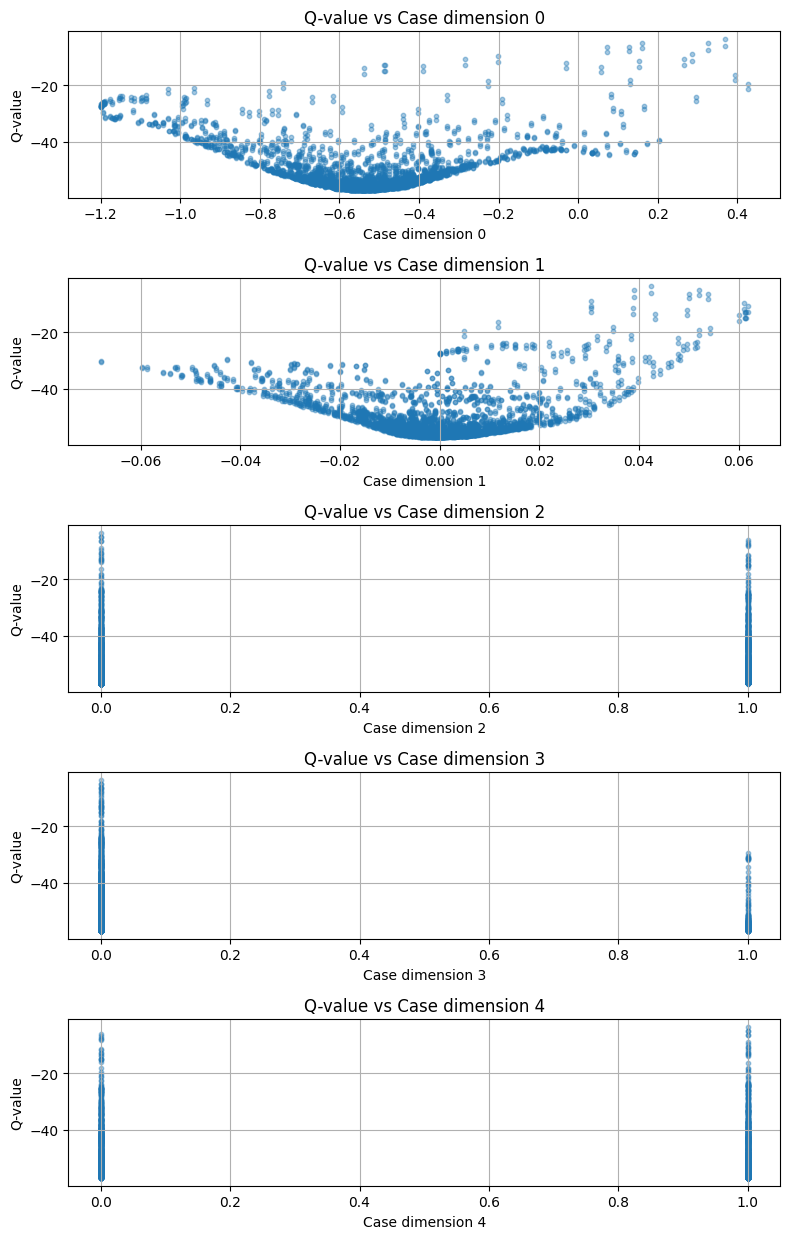

In [34]:
import torch
import matplotlib.pyplot as plt

# Ensure tensors are on CPU and detached
cases = cases_tensor.detach().cpu()
labels = labels_tensor.detach().cpu().view(-1)

num_features = cases.shape[1]

fig, axes = plt.subplots(
    nrows=num_features,
    ncols=1,
    figsize=(8, 2.5 * num_features),
    sharex=False
)

# If only one feature, axes is not iterable
if num_features == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.scatter(
        cases[:, i],
        labels,
        alpha=0.4,
        s=10
    )
    ax.set_xlabel(f"Case dimension {i}")
    ax.set_ylabel("Q-value")
    ax.set_title(f"Q-value vs Case dimension {i}")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [35]:
import numpy as np
import matplotlib.pyplot as plt

regime_weights = False

def plot_y_distribution(y, bin_width=0.1, title="y distribution", show_kde=False):
    """
    Plot a histogram of y with fixed bin width (default 0.1).

    Args:
        y: list | np.ndarray | pd.Series | torch.Tensor
        bin_width: float, width of each bin
        title: str
        show_kde: bool, overlay a simple kernel density (optional)
    """
    # to numpy
    try:
        import torch
        if isinstance(y, torch.Tensor):
            y = y.detach().cpu().numpy()
    except Exception:
        pass
    y = np.asarray(y, dtype=float).ravel()
    y = y[~np.isnan(y)]

    # bins
    y_min, y_max = np.min(y), np.max(y)
    # include the rightmost edge
    bins = np.arange(np.floor(y_min/bin_width)*bin_width,
                     np.ceil(y_max/bin_width)*bin_width + bin_width,
                     bin_width)

    # plot
    plt.figure(figsize=(7,4.5))
    counts, edges, _ = plt.hist(y, bins=bins, edgecolor='black', alpha=0.8)
    plt.xlabel("y")
    plt.ylabel("count")
    plt.title(f"{title} (bin={bin_width})")

    # optional KDE (very light, no seaborn)
    if show_kde:
        from scipy.stats import gaussian_kde
        xs = np.linspace(edges[0], edges[-1], 512)
        kde = gaussian_kde(y, bw_method='scott')
        # scale KDE to histogram counts
        plt.plot(xs, kde(xs) * len(y) * bin_width, linewidth=2)

    plt.tight_layout()
    plt.show()
    return counts, edges

### Configure NN-kNN for regression

In [36]:
cfg = {
    **default_args,
    "task_type": "regression",

    "case_score_mode": "bias_minus_distance",
    # "hard_knn",      # start here (closest to KNN)
    # other options you can try:
    # "bias_minus_distance"
    # "neg_distance_logw"
    # "sigmoid"                (your old style, if you want it back)
    # "hard_knn"               (uniform KNN weights)

    "softmax_over_cases": True,      # model enforces True in regression; kept explicit for clarity
    "tau": 0.3 ,# 1.0,                      # attention sharpness over cases, lower -> sharper
    "case_normalizer": "softmax",  # 'softmax' | 'sparsemax' | 'entmax15'
    # "case_norm_warmup_epochs": 0,       # 50–200 is a good sweep， 0 if no warm-up
    # "case_norm_warmup_type": "softmax",   # warm-up normalizer

    #for locality regularization in regression
    "regression_locality": False,  # Whether to use locality regularization in regression training
    "lambda_base": 1.0,
    # "lambda_kl": 0.0,        # weight for KL(p||w) attention-to-label proximity (regression only)
    "locality_alpha" : 2.0,    # exponent for distance in locality regularization
    "lambda_expdist": 0.1,   #1.0, weight for expected distance loss (regression only)
    # "lambda_balance": 0.0,    # weight for signed-bias regularizer (regression only)
    # "lambda_cover": 0.0,     #0.5, weight for coverage loss (regression
    # "lambda_pair": 0.0,      #0.5, weight for pos>neg pairwise hinge (regression only)
    # "lambda_ent": 0.0,  # 0.0,      #1e-3, tiny entropy penalty (encourages sparse attention tails)
    # "eps_sigma_multiplier": 0.1, #0.2,0.4 multiplier for sigma_y to define "close" and "far" in pairwise loss
    # "pairwise_margin": 0.05, # required gap: w_pos - w_neg >= margin

    # "locality_warmup_epochs": 0,   # epochs with locality off
    # "locality_ramp_epochs": 0,   # linearly ramp to full strength
    # "locality_schedule": "linear",  # (only linear implemented below)

    # "pre_topk_mask": False,   # enable the pre-normalization K-sparsification, if turned on, this influences nn-cdh to only adapt to top_k neighbors
    # "top_k": 40,         # K for Neighbor Agreement / nDCG in validation and also for explanation mode

    ## NEW
    # "bias_manual_set": True,
    # "bias_manual_value": 0.0,
    # #loss in the main training loop
    # "lambda_case_bias": 1e-3, #1e-3,    # weight for L2 regularization on case bias terms

    # "glocal_fw_set_num": 1, #1
    # "neg_weight_flag": False,        # regression should NOT use negative class weights
    # "sampling_cases_flag": False,    # use all cases for stable regression
    # "case_activation_by_top_k_average": True,  # use percentile-based bias finder
    # "top_k_for_default_case_activation": 20, #mark.
    # "case_activation_default_percentage": 0.1,
    "training_epochs": 7000,
    "batch_size": 64,
    "feature_extractor_lr": 1e-3, #1e-3,1e-4,1e-3,
    "glocal_weightor_lr": 1e-3, #1e-3,5e-4, 1e-3, influence feature weights and glocal weights
    "case_net_lr": 3e-4, #3e-4,1e-4,1e-5,
    "checkpoint_path": "nnknn_regression_best.pth",
    "patience": 80,

    #default feature extractor
    "post_mlp_enabled": False,
    # "post_mlp_dims": (64, 32),
    # "post_mlp_dropout": 0.1,
    # "post_mlp_activation": "relu",

    #Turn them all True or False to turn on/off nn_cdh adaptation
    "nn_cdh_pretrain": False,  # Whether to pretrain nn_cdh adapter
    "use_nn_cdh": False,
    "cdh_aggregate": False,  # "weighted_sum" | "attention"

    "explanation_mode": True
}

# No feature extractor for tabular demo
feature_extractor = None

## Train Model

In [37]:
#already standardized y
# y_mean = y_train.mean()
# y_std = y_train.std().clamp(min=1e-6)
y_train_norm = y_train # (y_train - y_mean) / y_std
y_val_norm   = y_val   # (y_val   - y_mean) / y_std

In [38]:
#train with normalized y
best_acc, glocal_weightor, model = train_model(
    X_train, y_train_norm, X_val, y_val_norm,
    feature_extractor=feature_extractor,
    cfg=cfg
)

print('Best (R^2 proxy in logs).')

cases trainable: False
labels trainable: False
Enforcing softmax_over_cases = True for regression task.
Number of feature extractor parameters: 0
Number of glocal weightor parameters: 1
torch.Size([1, 5])
Number of adapter parameters: 0
Number of case_net_params: 3
torch.Size([3200])
torch.Size([3200])
torch.Size([3200, 1])
*****************
Training started for training_epochs epochs with batch size 64

[Stage 1] Retrieval-only training for up to 7000 epochs (patience=80)
[Stage1] Epoch 1 - Val R²: 0.9597 | Reg Val Loss: 0.0462
[Stage1] New best (epoch 1) Val Loss: 0.0462 — saved: nnknn_regression_best_retr.pth
[Stage1] Epoch 2 - Val R²: 0.9642 | Reg Val Loss: 0.0410
[Stage1] New best (epoch 2) Val Loss: 0.0410 — saved: nnknn_regression_best_retr.pth
[Stage1] Epoch 3 - Val R²: 0.9678 | Reg Val Loss: 0.0369
[Stage1] New best (epoch 3) Val Loss: 0.0369 — saved: nnknn_regression_best_retr.pth
[Stage1] Epoch 4 - Val R²: 0.9708 | Reg Val Loss: 0.0334
[Stage1] New best (epoch 4) Val Loss: 0

## Evaluate and Visualize

Validation RMSE (z): 0.0389
Validation RMSE (raw): 0.3102


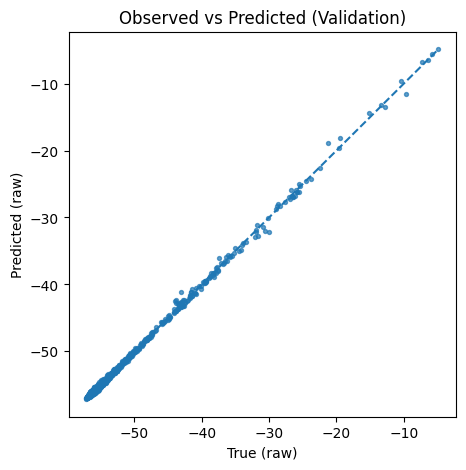

In [40]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch

model.eval()
with torch.no_grad():
    preds = []
    B = 512
    for i in range(0, X_val.size(0), B):
        _, yhat, *_ = model(X_val[i:i+B].to(device))
        preds.append(yhat.detach().cpu())

    y_pred_z = torch.cat(preds, dim=0).view(-1)   # CPU
    y_true_z = y_val.view(-1).detach().cpu()      # CPU

rmse_z = torch.sqrt(F.mse_loss(y_pred_z, y_true_z)).item()
print(f"Validation RMSE (z): {rmse_z:.4f}")

# Optional: convert to raw units
y_mean_t = torch.as_tensor(y_mean_raw, dtype=torch.float32)
y_std_t  = torch.as_tensor(y_std_raw, dtype=torch.float32).clamp_min(1e-6)

y_pred_raw = y_pred_z * y_std_t + y_mean_t
y_true_raw = y_true_z * y_std_t + y_mean_t

rmse_raw = torch.sqrt(F.mse_loss(y_pred_raw, y_true_raw)).item()
print(f"Validation RMSE (raw): {rmse_raw:.4f}")

plt.figure(figsize=(5,5))
plt.scatter(y_true_raw.numpy(), y_pred_raw.numpy(), s=8, alpha=0.7)
mn = float(min(y_true_raw.min().item(), y_pred_raw.min().item()))
mx = float(max(y_true_raw.max().item(), y_pred_raw.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True (raw)')
plt.ylabel('Predicted (raw)')
plt.title('Observed vs Predicted (Validation)')
plt.show()

[Z] Pre-adaptation  MSE: 0.001513, RMSE: 0.038895
[Z] Post-adaptation MSE: 0.001513, RMSE: 0.038895
[Z] ΔRMSE (pre - post):  0.000000
[RAW] Pre-adaptation  RMSE: 0.310237
[RAW] Post-adaptation RMSE: 0.310237


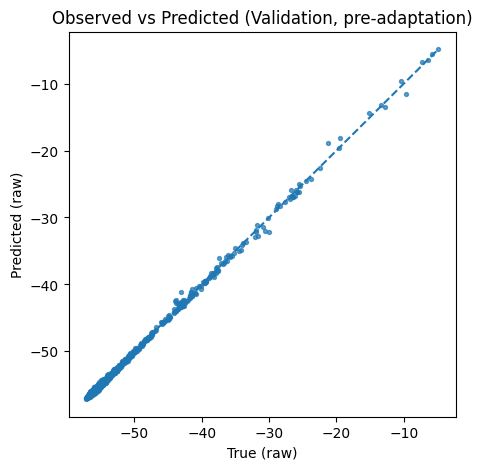

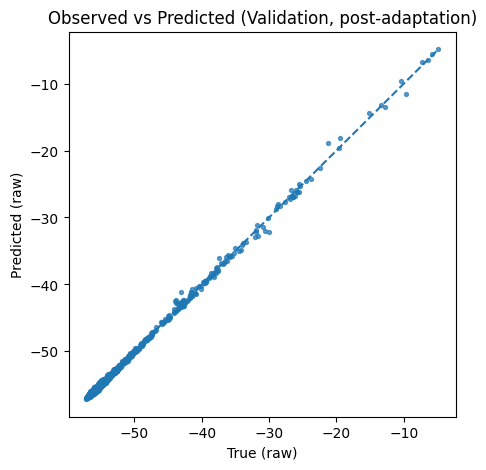

In [41]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    pre_preds, post_preds = [], []
    B = 512
    for i in range(0, X_val.size(0), B):
        _, yhat, pre_adapt_yhat, *_ = model(X_val[i:i+B].to(device))

        # pre_adapt_yhat may come in different shapes depending on code path
        if pre_adapt_yhat.dim() == 3:
            pre_yhat = pre_adapt_yhat.sum(dim=1).squeeze(-1)  # [B]
        elif pre_adapt_yhat.dim() == 2:
            pre_yhat = pre_adapt_yhat.squeeze(-1)             # [B]
        else:
            pre_yhat = pre_adapt_yhat                         # [B]

        post_preds.append(yhat.detach().cpu().view(-1))
        pre_preds.append(pre_yhat.detach().cpu().view(-1))

    y_pred_post_z = torch.cat(post_preds, dim=0).to(torch.float32)  # z-space
    y_pred_pre_z  = torch.cat(pre_preds,  dim=0).to(torch.float32)  # z-space
    y_true_z      = y_val.detach().cpu().view(-1).to(torch.float32) # z-space

# --- Metrics in z-space (always correct for training/val consistency) ---
mse_pre_z  = F.mse_loss(y_pred_pre_z,  y_true_z).item()
mse_post_z = F.mse_loss(y_pred_post_z, y_true_z).item()
rmse_pre_z  = mse_pre_z ** 0.5
rmse_post_z = mse_post_z ** 0.5

print(f"[Z] Pre-adaptation  MSE: {mse_pre_z:.6f}, RMSE: {rmse_pre_z:.6f}")
print(f"[Z] Post-adaptation MSE: {mse_post_z:.6f}, RMSE: {rmse_post_z:.6f}")
print(f"[Z] ΔRMSE (pre - post):  {rmse_pre_z - rmse_post_z:.6f}")

# --- Optional: convert to raw units if you saved train-split scaler ---
# (RMSE_raw = RMSE_z * y_std_raw)
y_mean_t = torch.as_tensor(y_mean_raw, dtype=torch.float32)
y_std_t  = torch.as_tensor(y_std_raw,  dtype=torch.float32).clamp_min(1e-6)

y_pred_pre_raw  = y_pred_pre_z  * y_std_t + y_mean_t
y_pred_post_raw = y_pred_post_z * y_std_t + y_mean_t
y_true_raw      = y_true_z      * y_std_t + y_mean_t

rmse_pre_raw  = torch.sqrt(F.mse_loss(y_pred_pre_raw,  y_true_raw)).item()
rmse_post_raw = torch.sqrt(F.mse_loss(y_pred_post_raw, y_true_raw)).item()
print(f"[RAW] Pre-adaptation  RMSE: {rmse_pre_raw:.6f}")
print(f"[RAW] Post-adaptation RMSE: {rmse_post_raw:.6f}")

# Plots in raw units (more interpretable)
plt.figure(figsize=(5,5))
plt.scatter(y_true_raw.numpy(), y_pred_pre_raw.numpy(), s=8, alpha=0.7)
mn = float(min(y_true_raw.min().item(), y_pred_pre_raw.min().item()))
mx = float(max(y_true_raw.max().item(), y_pred_pre_raw.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True (raw)')
plt.ylabel('Predicted (raw)')
plt.title('Observed vs Predicted (Validation, pre-adaptation)')
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_true_raw.numpy(), y_pred_post_raw.numpy(), s=8, alpha=0.7)
mn = float(min(y_true_raw.min().item(), y_pred_post_raw.min().item()))
mx = float(max(y_true_raw.max().item(), y_pred_post_raw.max().item()))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('True (raw)')
plt.ylabel('Predicted (raw)')
plt.title('Observed vs Predicted (Validation, post-adaptation)')
plt.show()

### Test a single case

In [42]:
import random
import torch

def test_single_case(model, X_mean, X_std, y_mean, y_std):
    index = random.randint(1, 3000)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load raw sample
    x_raw = cases_tensor[index].to(device).float()

    # Split state & action
    x_state  = x_raw[:4]    # (4,)
    x_action = x_raw[4:]    # (A,)

    # Ensure mean/std are 1-D
    mean = X_mean.to(device).view(-1)
    std  = X_std.to(device).view(-1)

    # Standardize STATE only
    x_state_z = (x_state - mean) / std

    # Reassemble full input
    x = torch.cat([x_state_z, x_action], dim=0)

    # Add batch dimension
    x = x.unsqueeze(0)

    # Inference
    model.eval()
    with torch.no_grad():
        pred_z, *_ = model(x)   # model outputs z-space

    # ---- De-normalize prediction ----
    pred_z_val = pred_z.item()

    y_mean_f = float(y_mean)
    y_std_f  = float(y_std)

    pred_raw = pred_z_val * y_std_f + y_mean_f

    # Output exactly as requested
    print(f"Predicted value (z):   {pred_z_val:.3f}")
    print(f"Predicted value (raw): {pred_raw:.3f}")
    print(f"Expected value: {labels_tensor[index]}")
    print(f"Index: {index}")

Predicted value (z): -0.689
This is the model’s prediction in standardized units. It means the predicted target is about 0.689 standard deviations below the training-set mean of y.

Predicted value (raw): -56.463
This is the same prediction after undoing normalization:
raw = z * y_std + y_mean
This is the number you usually care about.

Expected value: -56.70756530761719
This is the actual stored label for that selected case, taken directly from labels_tensor[2544].

Index: 2544
This tells you which case in cases_tensor was tested


In [43]:
test_single_case(model, X_mean, X_std, y_mean, y_std)

Predicted value (z):   -0.689
Predicted value (raw): -56.463
Expected value: -56.70756530761719
Index: 2544


In [45]:
maxes = []
for i in range(1000):
  x_rand = torch.rand((1, 6))
  with torch.no_grad():
      pred, *_ = model(x_rand)
  maxes.append(pred.item())

print(max(maxes))
print(f"Random input prediction: {pred.item():.3f}")

RuntimeError: The size of tensor a (6) must match the size of tensor b (5) at non-singleton dimension 2

### Evaluate the NN-kNN

In [49]:
import gymnasium as gym
import torch
import numpy as np


def evaluate_nnknn_cartpole(model, X_mean, X_std, y_mean=None, y_std=None, episodes=10):
    """
    Evaluates NN-kNN CartPole policy using the SAME training normalization:
      - state: z-score with X_mean/X_std (TRAIN stats)
      - action: one-hot (raw)
      - output: model returns normalized Q by default; argmax works on normalized Q.
        If y_mean/y_std are provided, we denormalize Q for logging only.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # env = gym.make("CartPole-v1")
    env = gym.make("MountainCar-v0", render_mode="rgb_array")

    model.eval().to(device)

    # Ensure normalization tensors are on the correct device / shape
    # X_mean/X_std were computed on state only -> expected shape (1, 4) or (4,)
    X_mean = torch.as_tensor(X_mean, dtype=torch.float32, device=device).view(1, 4)
    X_std  = torch.as_tensor(X_std,  dtype=torch.float32, device=device).view(1, 4).clamp_min(1e-6)

    # Optional y denorm stats (for logging only)
    if y_mean is not None and y_std is not None:
        y_mean = float(torch.as_tensor(y_mean).item())
        y_std  = float(torch.as_tensor(y_std).item())
        use_y_denorm = True
    else:
        use_y_denorm = False

    total_rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        ep_reward = 0.0

        while not done:
            # ---- state -> tensor -> z-score using TRAIN stats ----
            state_t = torch.as_tensor(state, dtype=torch.float32, device=device).view(1, 4)
            state_t = (state_t - X_mean) / X_std

            q_values = []

            for action in range(env.action_space.n):
                # ---- one-hot action (raw, NOT standardized) ----
                action_onehot = torch.zeros((1, env.action_space.n), dtype=torch.float32, device=device)
                action_onehot[0, action] = 1.0

                # ---- [state_z(4), action_oh(2)] ----
                sa_input = torch.cat([state_t, action_onehot], dim=1)

                with torch.no_grad():
                    pred, *_ = model(sa_input)     # pred is typically shape [1] or [1,1] depending on your model

                q_norm = float(pred.view(-1)[0].item())

                # Denormalize only if you want interpretable Q logging (NOT needed for argmax)
                if use_y_denorm:
                    q = q_norm * y_std + y_mean
                    q_values.append(q)
                else:
                    q_values.append(q_norm)

            best_action = int(np.argmax(q_values))

            next_state, reward, terminated, truncated, _ = env.step(best_action)
            done = terminated or truncated

            ep_reward += float(reward)
            state = next_state

        total_rewards.append(ep_reward)
        print(f"Episode {ep + 1}/{episodes} | Reward: {ep_reward:.1f}")

    env.close()

    avg_reward = float(np.mean(total_rewards))
    print(f"\nAverage Reward over {episodes} episodes: {avg_reward:.2f}")
    return avg_reward

In [50]:
avg_reward = evaluate_nnknn_cartpole(model, X_mean, X_std, y_mean=y_mean, y_std=y_std, episodes=10)

RuntimeError: shape '[1, 4]' is invalid for input of size 2

### Dive deeper into one episode

In [ ]:
import gymnasium as gym
import torch
import numpy as np


def evaluate_nnknn_vs_dqn_cartpole(
    model,
    policy_net,
    X_mean, X_std,
    y_mean=None, y_std=None,
    episodes=1,
    render=False,
    log_every=5,          # e.g., 50 prints every 50 steps; 0 disables
):
    """
    Evaluate NN-kNN greedy policy on CartPole while also printing DQN (policy_net) Q-values
    at the same states for comparison.

    NN-kNN input: [standardized_state(4), action_onehot(2)]
    DQN input: raw_state(4)  (typical CartPole DQN)

    Action selection is done using NN-kNN normalized Qs (argmax). DQN is only logged.

    Prints (when log_every triggers):
      - raw state
      - NN-kNN Q_norm (+ optional Q_denorm)
      - DQN Q
      - chosen actions and disagreement
      - margins
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env = gym.make("MountainCar-v0", render_mode="human" if render else None)

    model.eval().to(device)
    policy_net.eval().to(device)

    # State standardization stats (TRAIN stats, state only)
    X_mean_t = torch.as_tensor(X_mean, dtype=torch.float32, device=device).view(1, 4)
    X_std_t  = torch.as_tensor(X_std,  dtype=torch.float32, device=device).view(1, 4).clamp_min(1e-6)

    # Optional y denorm stats (for NN-kNN Q readability only)
    use_y_denorm = (y_mean is not None) and (y_std is not None)
    if use_y_denorm:
        y_mean_f = float(torch.as_tensor(y_mean).view(-1)[0].item())
        y_std_f  = float(torch.as_tensor(y_std).view(-1)[0].item())
    else:
        y_mean_f, y_std_f = 0.0, 1.0

    total_rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        ep_reward = 0.0
        step = 0

        while not done:
            # -------- RAW state for DQN --------
            state_raw_t = torch.as_tensor(state, dtype=torch.float32, device=device).view(1, 4)

            # -------- Standardized state for NN-kNN --------
            state_std_t = (state_raw_t - X_mean_t) / X_std_t

            # ---- NN-kNN Q(s,a) by evaluating both actions ----
            nn_q_norm = []
            nn_q_log  = []

            for action in range(env.action_space.n):
                action_onehot = torch.zeros((1, env.action_space.n), dtype=torch.float32, device=device)
                action_onehot[0, action] = 1.0

                sa_input = torch.cat([state_std_t, action_onehot], dim=1)  # (1,6)

                with torch.no_grad():
                    out = model(sa_input)

                pred = out[0] if isinstance(out, (tuple, list)) else out
                qn = float(pred.view(-1)[0].item())
                nn_q_norm.append(qn)

                if use_y_denorm:
                    nn_q_log.append(qn * y_std_f + y_mean_f)
                else:
                    nn_q_log.append(qn)

            nn_action = int(np.argmax(nn_q_norm))

            # ---- DQN Q(s,·) directly from policy_net on RAW state ----
            with torch.no_grad():
                dqn_out = policy_net(state_raw_t)  # expected shape (1,2)
            dqn_q = dqn_out.view(-1).detach().cpu().numpy().astype(float).tolist()
            dqn_action = int(np.argmax(dqn_q))

            # ---- Margins (how "confident" each model is) ----
            nn_margin = float(np.max(nn_q_norm) - np.min(nn_q_norm))
            dqn_margin = float(np.max(dqn_q) - np.min(dqn_q))
            disagree = (nn_action != dqn_action)

            # ---- Logging ----
            if log_every and (step % log_every == 0):
                state_np = np.array(state, dtype=np.float32)

                if use_y_denorm:
                    print(
                        f"[ep {ep+1} step {step}] "
                        f"NN(Q_denorm): a0={nn_q_log[0]:.4f}, a1={nn_q_log[1]:.4f} | "
                        f"NN(Q_norm): a0={nn_q_norm[0]:.4f}, a1={nn_q_norm[1]:.4f} | "
                        f"NN_pick={nn_action} (margin={nn_margin:.4f}) || "
                        f"DQN(Q): a0={dqn_q[0]:.4f}, a1={dqn_q[1]:.4f} | "
                        f"DQN_pick={dqn_action} (margin={dqn_margin:.4f}) || "
                        f"disagree={disagree} | state={state_np}"
                    )
                else:
                    print(
                        f"[ep {ep+1} step {step}] "
                        f"NN(Q_norm): a0={nn_q_norm[0]:.4f}, a1={nn_q_norm[1]:.4f} | "
                        f"NN_pick={nn_action} (margin={nn_margin:.4f}) || "
                        f"DQN(Q): a0={dqn_q[0]:.4f}, a1={dqn_q[1]:.4f} | "
                        f"DQN_pick={dqn_action} (margin={dqn_margin:.4f}) || "
                        f"disagree={disagree} | state={state_np}"
                    )

            # ---- Step env using NN-kNN action ----
            next_state, reward, terminated, truncated, _ = env.step(nn_action)
            done = bool(terminated or truncated)
            ep_reward += float(reward)

            state = next_state
            step += 1

        total_rewards.append(ep_reward)
        print(f"Episode {ep + 1}/{episodes} | Reward: {ep_reward:.1f}")

    env.close()

    avg_reward = float(np.mean(total_rewards))
    print(f"\nAverage Reward over {episodes} episodes: {avg_reward:.2f}")
    return avg_reward

In [ ]:
avg = evaluate_nnknn_vs_dqn_cartpole(
    model=model,
    policy_net=policy_net,
    X_mean=X_mean, X_std=X_std,
    y_mean=y_mean, y_std=y_std,
    episodes=1,
    log_every=5
)


[ep 1 step 0] NN(Q_denorm): a0=95.3547, a1=92.4362 | NN(Q_norm): a0=1.3393, a1=1.2565 | NN_pick=0 (margin=0.0828) || DQN(Q): a0=91.4683, a1=91.4332 | DQN_pick=0 (margin=0.0351) || disagree=False | state=[ 0.02828936 -0.04205144 -0.00633879 -0.02205006]
[ep 1 step 5] NN(Q_denorm): a0=93.3306, a1=92.5765 | NN(Q_norm): a0=1.2819, a1=1.2605 | NN_pick=0 (margin=0.0214) || DQN(Q): a0=91.7625, a1=91.8600 | DQN_pick=1 (margin=0.0975) || disagree=True | state=[ 0.00068077 -0.23731801  0.02633248  0.2738986 ]
[ep 1 step 10] NN(Q_denorm): a0=92.2667, a1=91.9854 | NN(Q_norm): a0=1.2517, a1=1.2437 | NN_pick=0 (margin=0.0080) || DQN(Q): a0=92.0521, a1=92.1419 | DQN_pick=1 (margin=0.0898) || disagree=True | state=[-0.03095078 -0.04525372  0.06754705  0.04869049]
[ep 1 step 15] NN(Q_denorm): a0=92.1796, a1=92.0033 | NN(Q_norm): a0=1.2492, a1=1.2442 | NN_pick=0 (margin=0.0050) || DQN(Q): a0=92.5085, a1=92.4388 | DQN_pick=0 (margin=0.0697) || disagree=False | state=[-0.03567733  0.14461313  0.076862   -

In [ ]:
## run an example
num = random.randint(0, len(cases))
example = torch.tensor(
    cases[num][:4],
    dtype=torch.float32
).unsqueeze(0)   # shape (1, 4)

device = next(policy_net.parameters()).device
example = example.to(device)

# ---- DQN forward pass (raw state) ----
with torch.no_grad():
    dqn_q = policy_net(example)   # shape (1, 2)

print("DQN Q-values:", dqn_q.cpu().numpy())

X_mean_t = torch.as_tensor(X_mean, dtype=torch.float32, device=device).view(1, 4)
X_std_t  = torch.as_tensor(X_std,  dtype=torch.float32, device=device).view(1, 4).clamp_min(1e-6)

state_std = (example - X_mean_t) / X_std_t   # shape (1, 4)

# ---- action 0 one-hot ----
action0 = torch.tensor([[1.0, 0.0]], device=device)
sa0 = torch.cat([state_std, action0], dim=1)  # shape (1, 6)

# ---- action 1 one-hot ----
action1 = torch.tensor([[0.0, 1.0]], device=device)
sa1 = torch.cat([state_std, action1], dim=1)  # shape (1, 6)

# ---- NN-kNN forward passes ----
model.eval()
with torch.no_grad():
    out0 = model(sa0)
    out1 = model(sa1)

# handle (pred, *extras) or pred-only
q0_norm = float((out0[0] if isinstance(out0, (tuple, list)) else out0).view(-1)[0])
q1_norm = float((out1[0] if isinstance(out1, (tuple, list)) else out1).view(-1)[0])

print("NN-kNN Q_norm:", q0_norm, q1_norm)

## denormalize
q0 = q0_norm * y_std + y_mean
q1 = q1_norm * y_std + y_mean

print("NN-kNN Q_denorm:", q0, q1)

DQN Q-values: [[86.45617  80.144066]]
NN-kNN Q_norm: 1.0951844453811646 0.905781626701355
NN-kNN Q_denorm: tensor([[86.7497]]) tensor([[80.0726]])


/tmp/ipython-input-1288873415.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  example = torch.tensor(


## Watch NN-kNN play

### View the top activated cases

In [46]:
# Enable explanation mode and inspect the top-k contributing cases for a few samples
model.top_k_mode = True
k = model.top_k  # how many top cases to display (see model.top_k_explain default too)

sample_idx = torch.arange(min(5, X_val.size(0)))  # first few
with torch.no_grad():
    final_pred, pred_vals, _, cases, labels, acts = model(X_val[sample_idx].to(device))

final_pred = final_pred * y_std_t + y_mean_t
labels = labels * y_std_t + y_mean_t

print("\n The first few cases and their most activated neighbors: ")
for i in range(len(sample_idx)):
    print(f"\nSample {i} (True: {y_val[sample_idx[i]].item():.4f}, Pred: {final_pred[i].item():.4f}):")
    topk_acts, topk_indices = torch.topk(acts[i], k=k)
    #print the sample itself
    print(f"  Sample features: {X_val[sample_idx[i]].cpu().numpy()}")
    accumulated_label = 0.0
    for rank in range(k):
        case_idx = topk_indices[rank].item()
        case_act = topk_acts[rank].item()
        case_feat = cases[i][rank].cpu().numpy()
        case_label = labels[i][rank].item()
        print(f"  Neighbor {rank+1}: Index {case_idx}, Activation {case_act:.4f}, Label {case_label:.4f}, Features {case_feat}")
        accumulated_label += case_label * case_act
    print(f"case activations multiply case labels:{accumulated_label}")


 The first few cases and their most activated neighbors: 

Sample 0 (True: 4.7761, Pred: -13.4756):
  Sample features: [ 0.24224514  4.1123323  -0.8969944  -0.3156346   1.        ]
  Neighbor 1: Index 0, Activation 0.6453, Label -12.8318, Features [ 0.2366582  4.114679  -0.8969944 -0.3156346  1.       ]
  Neighbor 2: Index 1, Activation 0.2782, Label -13.9307, Features [-0.01456802  4.0301504  -0.8969944  -0.3156346   1.        ]
  Neighbor 3: Index 2, Activation 0.0289, Label -6.6560, Features [ 3.4787705  3.4937432  1.1144857 -0.3156346  0.       ]
  Neighbor 4: Index 3, Activation 0.0132, Label -20.8222, Features [-2.1552012  2.5903535 -0.8969944 -0.3156346  1.       ]
  Neighbor 5: Index 4, Activation 0.0097, Label -21.1576, Features [-2.4902132  2.133029  -0.8969944 -0.3156346  1.       ]
  Neighbor 6: Index 5, Activation 0.0084, Label -13.0252, Features [ 0.72164303  4.104368   -0.8969944  -0.3156346   1.        ]
  Neighbor 7: Index 6, Activation 0.0035, Label -34.1067, Feature

In [48]:
import os
import glob
import gymnasium as gym
import torch
import torch.nn.functional as F
from gymnasium.wrappers.rendering import RecordVideo
from IPython.display import Video

def run_nnknn_and_record(
    model,
    video_folder="videos_nnknn",
    env_id="MountainCar-v0",
    max_steps=500,
    action_dim=3,
):
    os.makedirs(video_folder, exist_ok=True)

    device = next(model.parameters()).device
    model.eval()

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(
        env,
        video_folder=video_folder,
        episode_trigger=lambda episode_id: True,
        name_prefix="nnknn_eval",
    )

    state, info = env.reset()

    for _ in range(max_steps):
        # state: MountainCar -> [position, velocity]
        state_t = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        state_t = state_t.repeat(action_dim, 1)  # shape: (action_dim, state_dim)

        # build one-hot actions
        action_ids = torch.arange(action_dim, device=device)
        action_onehot = F.one_hot(action_ids, num_classes=action_dim).float()

        # concatenate [state, one_hot(action)]
        x = torch.cat([state_t, action_onehot], dim=1)  # shape: (action_dim, 2 + action_dim)

        with torch.no_grad():
            out = model(x)

            # Handle models that return multiple outputs, like: _, yhat, *rest
            if isinstance(out, tuple):
                action_scores = out[1].view(-1)
            else:
                action_scores = out.view(-1)

            action = torch.argmax(action_scores).item()

        state, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            break

    env.close()

    mp4_files = sorted(glob.glob(os.path.join(video_folder, "*.mp4")))
    if not mp4_files:
        raise RuntimeError("No video file was created.")

    latest_video = mp4_files[-1]
    print(f"Saved video to: {latest_video}")
    return latest_video

video_path = run_nnknn_and_record(
    model,
    video_folder="videos_nnknn",
    env_id="MountainCar-v0",
    max_steps=500,
    action_dim=3,
)
Video(video_path, embed=True)

c:\Users\merec\Desktop\Research\NN-kNN\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\merec\Desktop\Research\NewestWork\NN-kNN\videos_nnknn folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Saved video to: videos_nnknn\nnknn_eval-episode-0.mp4


In [ ]:
#cartpole
import gymnasium as gym
import numpy as np
import torch
import imageio
from PIL import Image, ImageDraw, ImageFont

def _safe_load_font(size=14):
    """
    Portable font loader. Falls back to default font if truetype is unavailable.
    """
    try:
        return ImageFont.truetype("DejaVuSans.ttf", size=size)
    except Exception:
        return ImageFont.load_default()


def _denorm_state_from_feat(feat_1d, X_mean_1x4, X_std_1x4):
    """
    Convert a case feature vector into a raw CartPole state [x, x_dot, theta, theta_dot].

    Assumptions:
      - feat_1d is either:
          [state_z(4), action_onehot(2)]  (normalized state)
        or:
          [state_raw(4), action_onehot(2)] (already raw)
      - We treat the first 4 entries as state and denormalize with X_mean/X_std.
    """
    s = np.asarray(feat_1d, dtype=np.float32).reshape(-1)
    s4 = s[:4].copy()

    # Denormalize as: raw = z * std + mean
    mean = np.asarray(X_mean_1x4, dtype=np.float32).reshape(4)
    std = np.asarray(X_std_1x4, dtype=np.float32).reshape(4)
    std = np.clip(std, 1e-6, None)

    s_raw = s4 * std + mean
    return s_raw


def _draw_cartpole_scene(draw, box, state_raw, title=None, subtitle=None):
    """
    Draw a simple CartPole illustration inside `box` = (x0, y0, x1, y1)
    using `state_raw` = [x, x_dot, theta, theta_dot].
    """
    x0, y0, x1, y1 = box
    w = x1 - x0
    h = y1 - y0

    # Background
    draw.rectangle([x0, y0, x1, y1], fill=(250, 250, 250))

    # Layout constants
    margin = int(0.08 * w)
    title_h = int(0.22 * h)

    # Text
    font_title = _safe_load_font(16)
    font_sub = _safe_load_font(13)

    tx = x0 + margin
    ty = y0 + int(0.10 * title_h)

    if title is not None:
        draw.text((tx, ty), title, fill=(20, 20, 20), font=font_title)
        ty += int(1.0 * title_h)

    if subtitle is not None:
        draw.text((tx, ty), subtitle, fill=(60, 60, 60), font=font_sub)

    # Drawing region for physics
    phys_top = y0 + title_h
    phys_bottom = y1 - int(0.10 * h)
    phys_left = x0 + margin
    phys_right = x1 - margin

    # Track line
    track_y = phys_bottom
    draw.line([(phys_left, track_y), (phys_right, track_y)], fill=(120, 120, 120), width=2)

    # Map CartPole x to pixels
    # CartPole x typically in about [-2.4, 2.4] before termination; we clamp for drawing.
    cart_x = float(state_raw[0])
    theta = float(state_raw[2])

    x_clamp = max(-2.4, min(2.4, cart_x))
    t = (x_clamp + 2.4) / 4.8  # in [0,1]
    cart_center_x = int(phys_left + t * (phys_right - phys_left))

    # Cart geometry
    cart_w = int(0.18 * (phys_right - phys_left))
    cart_h = int(0.14 * (phys_bottom - phys_top))
    cart_y0 = track_y - cart_h
    cart_x0 = cart_center_x - cart_w // 2
    cart_x1 = cart_center_x + cart_w // 2
    cart_y1 = track_y

    # Cart body
    draw.rectangle([cart_x0, cart_y0, cart_x1, cart_y1], outline=(30, 30, 30), fill=(230, 230, 230), width=2)

    # Wheels
    wheel_r = max(2, int(0.12 * cart_h))
    wheel_y = track_y + wheel_r
    wheel_dx = int(0.30 * cart_w)
    for wx in (cart_center_x - wheel_dx, cart_center_x + wheel_dx):
        draw.ellipse([wx - wheel_r, wheel_y - wheel_r, wx + wheel_r, wheel_y + wheel_r],
                     outline=(30, 30, 30), fill=(245, 245, 245), width=2)

    # Pole geometry (theta=0 is upright)
    pivot = (cart_center_x, cart_y0)
    pole_len = int(0.75 * (phys_bottom - phys_top))

    # Pole tip: x = pivot_x + L*sin(theta), y = pivot_y - L*cos(theta)
    tip_x = int(pivot[0] + pole_len * np.sin(theta))
    tip_y = int(pivot[1] - pole_len * np.cos(theta))

    # Pole
    draw.line([pivot, (tip_x, tip_y)], fill=(200, 60, 60), width=5)

    # Pivot joint
    joint_r = max(3, int(0.10 * cart_h))
    draw.ellipse([pivot[0] - joint_r, pivot[1] - joint_r, pivot[0] + joint_r, pivot[1] + joint_r],
                 outline=(30, 30, 30), fill=(255, 255, 255), width=2)

    # Small guide tick for upright reference
    ref_x = pivot[0]
    ref_y = pivot[1] - pole_len
    draw.line([(ref_x, pivot[1]), (ref_x, ref_y)], fill=(170, 170, 170), width=2)


def _make_topk_cartpole_panel(
    height,
    width,
    step_idx,
    fps,
    state_raw,
    chosen_action,
    q_values,
    top_cases_feats,
    top_cases_labels,
    top_cases_indices,
    X_mean_1x4,
    X_std_1x4,
):
    """
    Right-side panel that draws the top-3 retrieved cases as CartPole sketches.
    """
    panel = Image.new("RGB", (width, height), color=(245, 245, 245))
    draw = ImageDraw.Draw(panel)

    font_h = _safe_load_font(15)
    font_s = _safe_load_font(13)

    # Header
    margin = 14
    t_sec = step_idx / float(fps)
    header_lines = [
        f"NN-kNN CartPole | t={t_sec:5.2f}s | step={step_idx}",
        f"Chosen action: {chosen_action} (0=Left, 1=Right)",
        f"Q0={q_values[0]: .4f}   Q1={q_values[1]: .4f}",
        f"Current state: x={state_raw[0]: .3f}, xdot={state_raw[1]: .3f}, theta={state_raw[2]: .3f}, thetadot={state_raw[3]: .3f}",
        "Top-3 retrieved cases (drawn):",
    ]

    y = margin
    for i, line in enumerate(header_lines):
        draw.text((margin, y), line, fill=(20, 20, 20), font=(font_h if i == 0 else font_s))
        y += 18

    # Split remaining space into 3 tiles
    tiles_top = y + 6
    tiles_h = height - tiles_top - margin
    tile_h = max(1, tiles_h // 3)
    tile_w = width - 2 * margin

    for r in range(3):
        y0 = tiles_top + r * tile_h
        y1 = tiles_top + (r + 1) * tile_h - 8
        x0 = margin
        x1 = margin + tile_w

        # Box border
        draw.rectangle([x0, y0, x1, y1], outline=(210, 210, 210), width=2)

        if r >= len(top_cases_feats):
            # In case fewer are available
            draw.text((x0 + 12, y0 + 10), f"#{r+1}: (missing)", fill=(80, 80, 80), font=font_s)
            continue

        feat = top_cases_feats[r]
        idx = int(top_cases_indices[r]) if top_cases_indices is not None else -1
        lab = float(top_cases_labels[r]) if top_cases_labels is not None else float("nan")

        case_state_raw = _denorm_state_from_feat(feat, X_mean_1x4=X_mean_1x4, X_std_1x4=X_std_1x4)

        title = f"#{r+1}  case_idx={idx}"
        subtitle = f"label(Q)={lab: .4f} | x={case_state_raw[0]: .3f} theta={case_state_raw[2]: .3f}"

        _draw_cartpole_scene(draw, (x0 + 8, y0 + 15, x1 - 8, y1 - 15), case_state_raw, title=title, subtitle=subtitle)

    return np.array(panel, dtype=np.uint8)


def record_nnknn_cartpole_with_topk_panel(
    model,
    X_mean,
    X_std,
    y_mean=None,
    y_std=None,
    out_path="nnknn_cartpole_explain.mp4",
    fps=30,
    seconds_between_updates=1.0,
    k=5,
    max_steps=2000,
    device=None,
    panel_width=520,
):
    """
    Records a single CartPole episode into an MP4:
      - Left: environment frames
      - Right: drawings of the top-3 retrieved cases (CartPole sketches), updated every `seconds_between_updates`

    Requirements:
      - gymnasium CartPole-v1 available
      - env created with render_mode="rgb_array"
      - model forward returns explanation tensors when model.top_k_mode=True:
          out = model(sa_input)
        where the LAST three outputs are assumed to be:
          cases, labels, acts
        (Adjust extraction below if your model differs.)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    env = gym.make("MountainCar-v0", render_mode="rgb_array")#env = gym.make("MountainCar-v0",
    model.eval().to(device)

    # Normalize tensors (for state only)
    X_mean_t = torch.as_tensor(X_mean, dtype=torch.float32, device=device).view(1, 4)
    X_std_t  = torch.as_tensor(X_std,  dtype=torch.float32, device=device).view(1, 4).clamp_min(1e-6)

    # Keep numpy copies for denorm of retrieved cases
    X_mean_np = X_mean_t.detach().cpu().numpy().reshape(1, 4)
    X_std_np  = X_std_t.detach().cpu().numpy().reshape(1, 4)

    use_y_denorm = (y_mean is not None and y_std is not None)
    if use_y_denorm:
        y_mean_f = float(torch.as_tensor(y_mean).item())
        y_std_f  = float(torch.as_tensor(y_std).item())
    else:
        y_mean_f, y_std_f = 0.0, 1.0

    # Enable top-k mode
    model.top_k_mode = True
    if hasattr(model, "top_k"):
        model.top_k = k

    update_every_n_frames = max(1, int(round(seconds_between_updates * fps)))

    state, _ = env.reset()
    done = False

    last_panel = None

    with imageio.get_writer(out_path, fps=fps, codec="libx264") as writer:
        step_idx = 0

        while not done and step_idx < max_steps:
            # Render env (left frame)
            frame = env.render()
            if frame is None:
                raise RuntimeError("env.render() returned None. Ensure render_mode='rgb_array'.")

            # Compute action via model
            state_raw = np.array(state, dtype=np.float32)

            state_t = torch.as_tensor(state_raw, dtype=torch.float32, device=device).view(1, 4)
            state_z = (state_t - X_mean_t) / X_std_t

            q_values = []
            sa_inputs = []

            for action in range(env.action_space.n):
                action_onehot = torch.zeros((1, env.action_space.n), dtype=torch.float32, device=device)
                action_onehot[0, action] = 1.0

                sa_input = torch.cat([state_z, action_onehot], dim=1)
                sa_inputs.append(sa_input)

                with torch.no_grad():
                    pred, *_ = model(sa_input)

                q_norm = float(pred.view(-1)[0].item())
                q = (q_norm * y_std_f + y_mean_f) if use_y_denorm else q_norm
                q_values.append(q)

            best_action = int(np.argmax(q_values))

            # Update the panel every N frames (draw top-3 cases)
            if (step_idx % update_every_n_frames) == 0 or last_panel is None:
                chosen_sa = sa_inputs[best_action]

                with torch.no_grad():
                    out = model(chosen_sa)

                if len(out) < 3:
                    raise RuntimeError("Model output too short; cannot find (cases, labels, acts).")

                # Assume last three are (cases, labels, acts)
                cases = out[-3]
                labels = out[-2]
                acts = out[-1]

                acts_1 = acts[0] if acts.dim() == 2 else acts
                topk_acts, topk_indices = torch.topk(acts_1, k=k)

                # Extract features/labels for single sample
                if cases.dim() >= 3:
                    topk_feats = cases[0, :k].detach().cpu().numpy()
                else:
                    topk_feats = cases[:k].detach().cpu().numpy()

                if labels.dim() >= 2:
                    topk_labels = labels[0, :k].detach().cpu().numpy()
                else:
                    topk_labels = labels[:k].detach().cpu().numpy()

                # Draw only top-3
                top_n = min(3, k)
                last_panel = _make_topk_cartpole_panel(
                    height=frame.shape[0],
                    width=panel_width,
                    step_idx=step_idx,
                    fps=fps,
                    state_raw=state_raw,
                    chosen_action=best_action,
                    q_values=q_values,
                    top_cases_feats=topk_feats[:top_n],
                    top_cases_labels=topk_labels[:top_n],
                    top_cases_indices=topk_indices.detach().cpu().numpy()[:top_n],
                    X_mean_1x4=X_mean_np,
                    X_std_1x4=X_std_np,
                )

            # Compose side-by-side
            right = last_panel
            if right.shape[0] != frame.shape[0]:
                right = np.array(Image.fromarray(right).resize((right.shape[1], frame.shape[0])))

            combined = np.concatenate([frame, right], axis=1)
            writer.append_data(combined)

            # Step env
            next_state, reward, terminated, truncated, _ = env.step(best_action)
            done = terminated or truncated
            state = next_state
            step_idx += 1

    env.close()
    return out_path

In [ ]:
video_path = record_nnknn_cartpole_with_topk_panel(
    model=model,
    X_mean=X_mean,
    X_std=X_std,
    y_mean=None,
    y_std=None,
    out_path="nnknn_cartpole_explain.mp4",
    fps=30,
    seconds_between_updates=0.5,
    k=3,
)

print("Saved:", video_path)


from IPython.display import Video
Video(video_path, embed=True)

Saved: nnknn_cartpole_explain.mp4
